# Forecast Diurnal Cycle Analysis
CESM2 S2S hindcast ensemble — diurnal cycle amplitude and phase by forecast lead day

- Composites are averaged over all selected start dates × ensemble members  
- Separate diurnal cycle is computed for each lead day (1, 2, 3, …)  
- Output: 2×3 panel Evans maps (phase=hue, amplitude=saturation) for lead days 1–6

In [1]:
import importlib
import sys
import os

sys.path.insert(0, '/glade/work/rneale/git/python-scripts/diurnal_cycle/forecast')
sys.path.insert(0, '/glade/work/rneale/git/python-scripts/diurnal_cycle')

import forecast_diurnal_utils as fcutils
import diurnal_cycle_utils    as dcutils
importlib.reload(fcutils)
importlib.reload(dcutils)

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

print('Imports OK')

Imports OK


In [2]:
# ============================================================
# SETTINGS
# ============================================================

data_dir  = fcutils.DATA_DIR
season     = 'DJF'
year_start = 2022
year_end   = 2023

nens_forecast = 5
ens_members   = list(range(nens_forecast))

nlead_days    = 10         # panel will show all 10 lead days (5×2 layout)
dt_hours      = 6
precip_vars   = ('TMQ',)

# --- Plot domain ---
domain = 'CONUS'    # 'GLOBAL' | 'US' | 'TROPICS' | 'CONUS'

_DOMAINS = {
    'GLOBAL':  {'lat_range': (-40.,  40.), 'lon_range': (-180., 180.)},
    'TROPICS': {'lat_range': (-20.,  20.), 'lon_range': (-180., 180.)},
    'US':      {'lat_range': ( 15.,  60.), 'lon_range': (-140.,  -55.)},
    'CONUS':   {'lat_range': ( 22.,  52.), 'lon_range': (-130.,  -65.)},
}
if domain not in _DOMAINS:
    raise ValueError(f"Unknown domain '{domain}'. Choose: {list(_DOMAINS)}")
lat_range   = _DOMAINS[domain]['lat_range']
lon_range   = _DOMAINS[domain]['lon_range']
show_states = domain in ('US', 'CONUS')

# --- Panel layout ---
n_cols = 5    # 5 columns × 2 rows = 10 panels

# --- Mean precip contour levels ---
# Tighter range for regional domains; None = use default global levels
prcp_levels = [0, 0.25, 0.5, 1, 1.5, 2, 3, 4] if domain in ('US', 'CONUS') else None

# --- Harmonic analysis ---
n_harm       = 2
harm_names   = ['Diurnal (H1, 24 h)', 'Semi-diurnal (H2, 12 h)']
harm_periods = [24.0, 12.0]
harm_fnames  = ['H1_diurnal', 'H2_semidiurnal']

# --- Evans plot settings ---
min_amp_list   = [0.5, 0.5]
max_amp_list   = [6.0, 5.0]
hue_offset     = 0.5
discrete_wheel = True
min_amp_raw    = 0.5
max_amp_raw    = 6.0

# --- Regional line plots ---
# Format: (lat_min, lat_max, lon_min, lon_max, mask_type)
# mask_type: 'land' = land points only, 'ocean' = ocean points only, None = all
regions_line = {
    'Midwest':        (35., 45., -100.,  -90., None),
    'Southeast US':   (25., 35.,  -92.,  -78., 'land'),   # FL, GA, SC, MS, AL
    'SE Coast Ocean': (30., 35.,  -80.,  -70., 'ocean'),  # ocean off SE US coast
}

# --- Output ---
dir_fig = '/glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/'
os.makedirs(dir_fig, exist_ok=True)

print(f'Season:       {season}  {year_start}–{year_end}')
print(f'Ensemble:     members {ens_members}')
print(f'Lead days:    1–{nlead_days}  ({n_cols} cols × 2 rows)')
print(f'Domain:       {domain}  states={show_states}')
print(f'Precip levels: {prcp_levels}')
for rname, rdef in regions_line.items():
    mt = rdef[4] if len(rdef) > 4 else None
    print(f'  {rname}: {rdef[:4]}  mask={mt}')

Season:       DJF  2022–2023
Ensemble:     members [0, 1, 2, 3, 4]
Lead days:    1–10  (5 cols × 2 rows)
Domain:       CONUS  states=True
Precip levels: [0, 0.25, 0.5, 1, 1.5, 2, 3, 4]
  Midwest: (35.0, 45.0, -100.0, -90.0)  mask=None
  Southeast US: (25.0, 35.0, -92.0, -78.0)  mask=land
  SE Coast Ocean: (30.0, 35.0, -80.0, -70.0)  mask=ocean


In [3]:
importlib.reload(fcutils)

# Find available start dates for the chosen season and year range
start_dates = fcutils.get_start_dates(
    data_dir,
    season=season,
    year_start=year_start,
    year_end=year_end,
)

print(f'Start dates found: {len(start_dates)}')
print(f'  First: {start_dates[0]}   Last: {start_dates[-1]}')
print(f'Total files to load: {len(start_dates) * len(ens_members)}')

Start dates found: 22
  First: 2022-01-03   Last: 2023-02-27
Total files to load: 110


In [4]:
importlib.reload(fcutils)

print(f'Loading {len(start_dates)} start dates × {len(ens_members)} members '
      f'→ {nlead_days} lead days ...')

dc_leads = fcutils.load_forecast_diurnal(
    data_dir    = data_dir,
    start_dates = start_dates,
    ens_members = ens_members,
    nlead_days  = nlead_days,
    dt_hours    = dt_hours,
    precip_vars = precip_vars,
)

lat = dc_leads['lat'].values
lon = dc_leads['lon'].values

print(f'\ndc_leads shape: {dc_leads.shape}')
print(f'  dims: {dict(dc_leads.sizes)}')
print(f'  lat:  {lat[0]:.2f} to {lat[-1]:.2f}')
print(f'  lon:  {lon[0]:.2f} to {lon[-1]:.2f}')
print(f'  time-of-day (UTC h): {dc_leads["time_of_day"].values}')

# Quick sanity check: mean precip per lead day
for d in range(nlead_days):
    m = float(np.nanmean(dc_leads.isel(lead_day=d)))
    print(f'  Lead day {d+1}: mean precip = {m:.3f} mm/day')

Loading 22 start dates × 5 members → 10 lead days ...
  100/110  loaded=100  missing=0  no_precip=0
  Done: 110/110 files loaded  (0 missing, 0 no precip variable)

dc_leads shape: (10, 4, 192, 288)
  dims: {'lead_day': 10, 'time_of_day': 4, 'lat': 192, 'lon': 288}
  lat:  -90.00 to 90.00
  lon:  -180.00 to 178.75
  time-of-day (UTC h): [ 0.  6. 12. 18.]
  Lead day 1: mean precip = 1554605440.000 mm/day
  Lead day 2: mean precip = 1561862400.000 mm/day
  Lead day 3: mean precip = 1557726336.000 mm/day
  Lead day 4: mean precip = 1554590720.000 mm/day
  Lead day 5: mean precip = 1553159552.000 mm/day
  Lead day 6: mean precip = 1554320256.000 mm/day
  Lead day 7: mean precip = 1556363520.000 mm/day
  Lead day 8: mean precip = 1557515776.000 mm/day
  Lead day 9: mean precip = 1557885696.000 mm/day
  Lead day 10: mean precip = 1558083328.000 mm/day


In [5]:
importlib.reload(fcutils)

# ============================================================
# HARMONIC ANALYSIS — all lead days
# ============================================================

amplitude, phase_utc, var_exp, mean_prcp = fcutils.compute_lead_harmonics(
    dc_leads, n_harm=n_harm, dt_hours=dt_hours)

# amplitude  : (nlead, n_harm, nlat, nlon)
# phase_utc  : (nlead, n_harm, nlat, nlon)
# var_exp    : (nlead, n_harm, nlat, nlon)
# mean_prcp  : (nlead, nlat, nlon)

# Convert UTC phase → local solar time for each lead day and harmonic
phase_lst = np.zeros_like(phase_utc)
for d in range(nlead_days):
    for ih in range(n_harm):
        phase_lst[d, ih] = fcutils.phase_utc_to_lst(
            phase_utc[d, ih], lon, harm_periods[ih])

# Raw diurnal max (lead-day composite)
amp_raw_list      = []
phase_lst_raw_list = []
for d in range(nlead_days):
    a_raw, ph_utc_raw = fcutils.compute_raw_diurnal(dc_leads.isel(lead_day=d),
                                                    dt_hours=dt_hours)
    amp_raw_list.append(a_raw)
    phase_lst_raw_list.append(fcutils.phase_utc_to_lst(ph_utc_raw, lon, 24.0))

amp_raw_leads      = np.stack(amp_raw_list)       # (nlead, nlat, nlon)
phase_lst_raw_leads = np.stack(phase_lst_raw_list)

print('Harmonic analysis complete.')
for d in range(nlead_days):
    for ih in range(n_harm):
        print(f'  Lead day {d+1}  H{ih+1}: '
              f'amp_max={np.nanmax(amplitude[d,ih]):.2f} mm/day  '
              f'var_exp_mean={np.nanmean(var_exp[d,ih]):.1%}')

Harmonic analysis complete.
  Lead day 1  H1: amp_max=400348608.00 mm/day  var_exp_mean=72.7%
  Lead day 1  H2: amp_max=276817792.00 mm/day  var_exp_mean=27.3%
  Lead day 2  H1: amp_max=286702144.00 mm/day  var_exp_mean=74.0%
  Lead day 2  H2: amp_max=171490752.00 mm/day  var_exp_mean=26.0%
  Lead day 3  H1: amp_max=289237536.00 mm/day  var_exp_mean=74.4%
  Lead day 3  H2: amp_max=189302592.00 mm/day  var_exp_mean=25.6%
  Lead day 4  H1: amp_max=239664432.00 mm/day  var_exp_mean=74.5%
  Lead day 4  H2: amp_max=170273920.00 mm/day  var_exp_mean=25.5%
  Lead day 5  H1: amp_max=324883008.00 mm/day  var_exp_mean=75.4%
  Lead day 5  H2: amp_max=232201472.00 mm/day  var_exp_mean=24.6%
  Lead day 6  H1: amp_max=254270208.00 mm/day  var_exp_mean=75.0%
  Lead day 6  H2: amp_max=154623552.00 mm/day  var_exp_mean=25.0%
  Lead day 7  H1: amp_max=257267536.00 mm/day  var_exp_mean=74.2%
  Lead day 7  H2: amp_max=138612992.00 mm/day  var_exp_mean=25.8%
  Lead day 8  H1: amp_max=227670832.00 mm/day  v

Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_regions_Midwest-Southeast_US-SE_Coast_Ocean.png


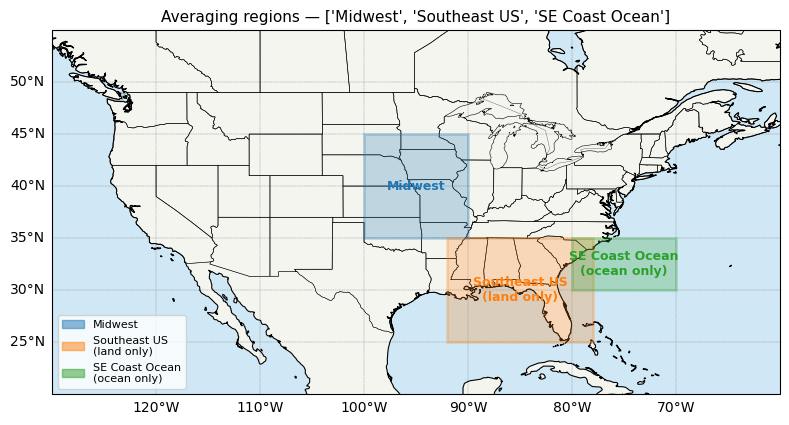

Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_mean_precip.png


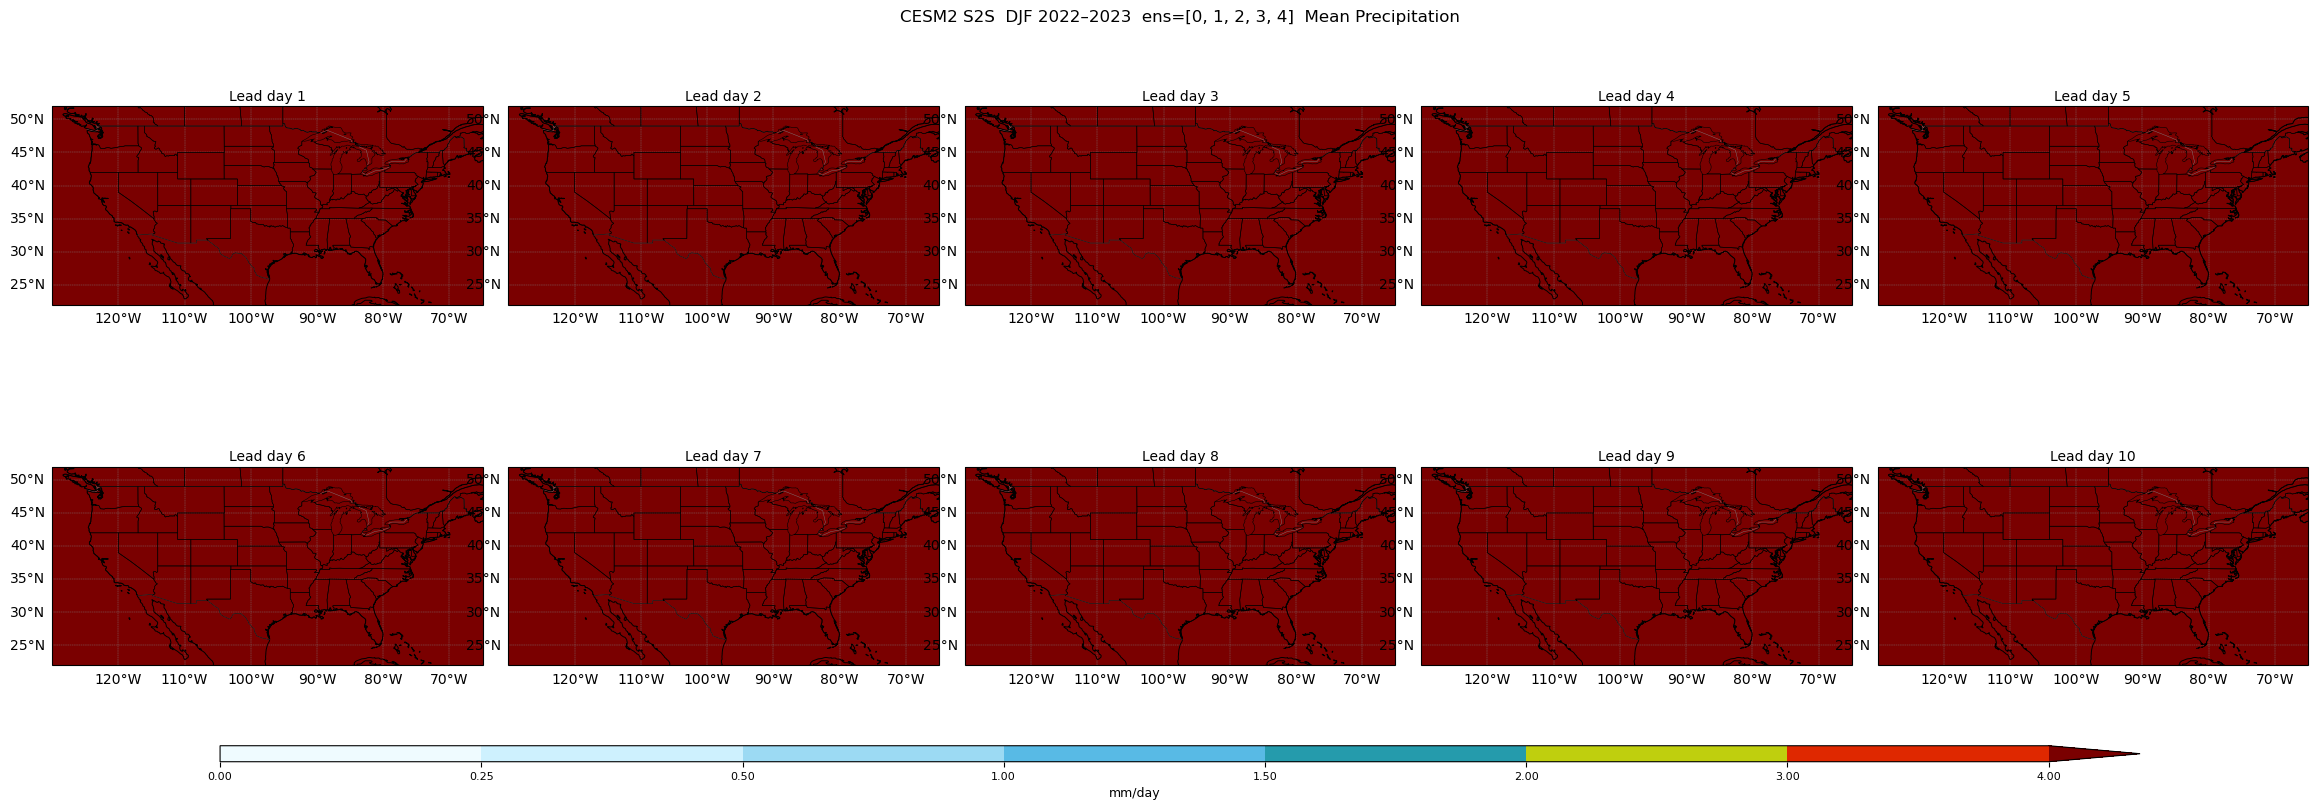

In [6]:
# ============================================================
# FIGURE 0: Region box map
# ============================================================

importlib.reload(fcutils)

fig = fcutils.plot_region_boxes(
    regions     = regions_line,
    lat_range   = (20., 55.),
    lon_range   = (-130., -60.),
    show_states = True,
    title       = f'Averaging regions — {list(regions_line.keys())}',
)
fname = os.path.join(dir_fig, f'forecast_regions_{"-".join(k.replace(" ","_") for k in regions_line)}.png')
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f'Saved: {fname}')
plt.show()

# ============================================================
# FIGURE 1: Mean Precipitation Panel (lead days 1–{nlead_days})
# ============================================================

fig = fcutils.plot_forecast_mean_panel(
    mean_prcp, lat, lon,
    lead_days   = dc_leads['lead_day'].values,
    lat_range   = lat_range,
    lon_range   = lon_range,
    show_states = show_states,
    n_cols      = n_cols,
    levels      = prcp_levels,
    title       = (f'CESM2 S2S  {season} {year_start}–{year_end}  '
                   f'ens={ens_members}  Mean Precipitation'),
)
fname = os.path.join(dir_fig,
    f'forecast_{domain}_{season}_{year_start}-{year_end}_mean_precip.png')
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f'Saved: {fname}')
plt.show()

Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_evans_H1_diurnal.png


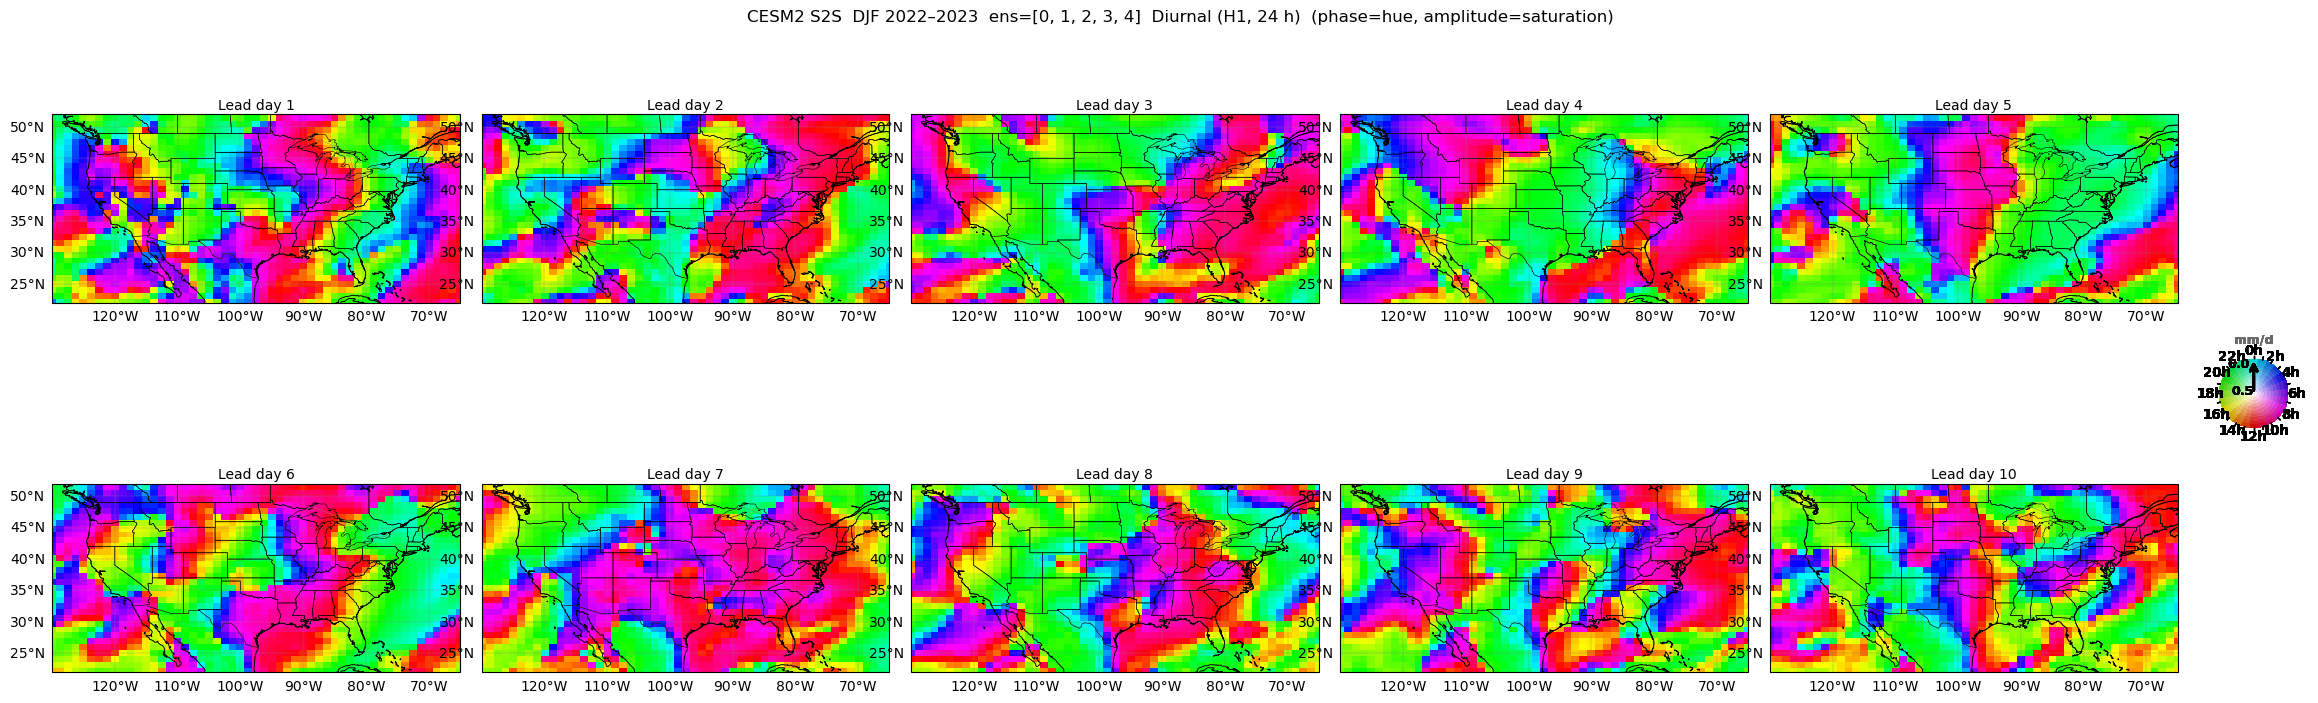

Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_evans_H2_semidiurnal.png


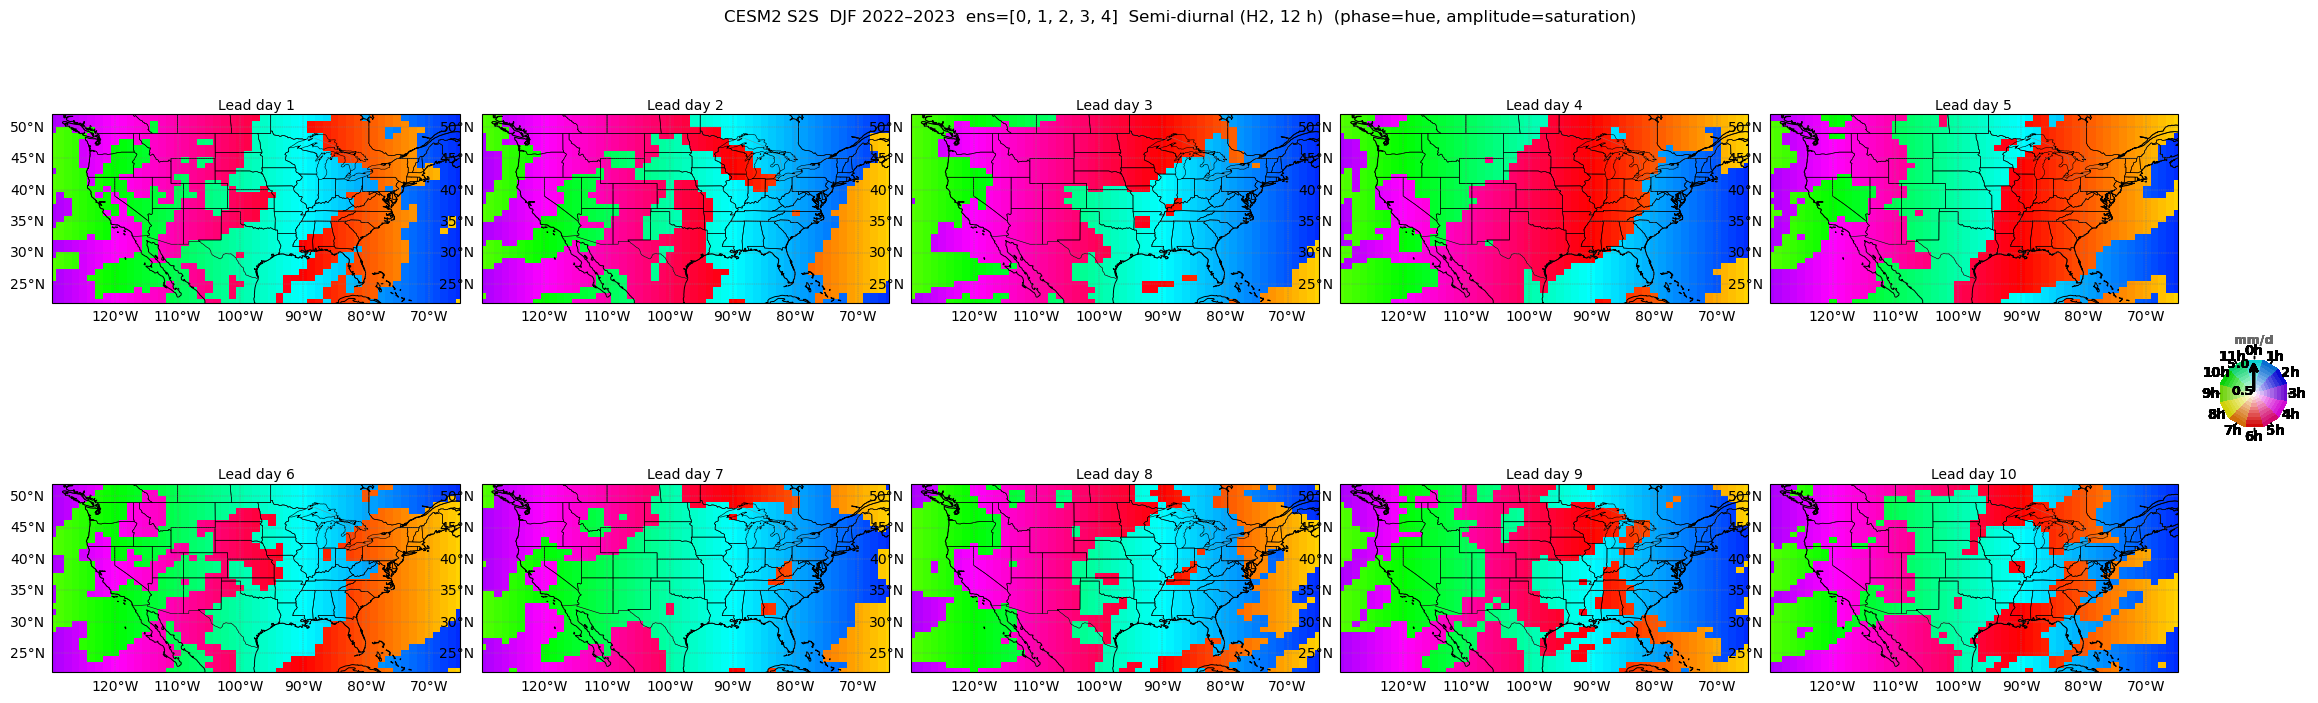

In [7]:
# ============================================================
# FIGURE 2+: Evans Phase/Amplitude Panel — one per harmonic
# ============================================================

for ih in range(n_harm):
    fig = fcutils.plot_forecast_panel(
        amplitude  = amplitude[:, ih],
        phase_lst  = phase_lst[:, ih],
        lat=lat, lon=lon,
        lead_days  = dc_leads['lead_day'].values,
        min_amp    = min_amp_list[ih],
        max_amp    = max_amp_list[ih],
        period_hours   = harm_periods[ih],
        hue_offset     = hue_offset,
        lat_range      = lat_range,
        lon_range      = lon_range,
        discrete_wheel = discrete_wheel,
        dt_hours       = dt_hours,
        show_states    = show_states,
        title      = (f'CESM2 S2S  {season} {year_start}–{year_end}  '
                      f'ens={ens_members}  {harm_names[ih]}  '
                      f'(phase=hue, amplitude=saturation)'),
    )

    fname = os.path.join(dir_fig,
        f'forecast_{domain}_{season}_{year_start}-{year_end}_evans_{harm_fnames[ih]}.png')
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname}')
    plt.show()

Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_evans_raw_max.png


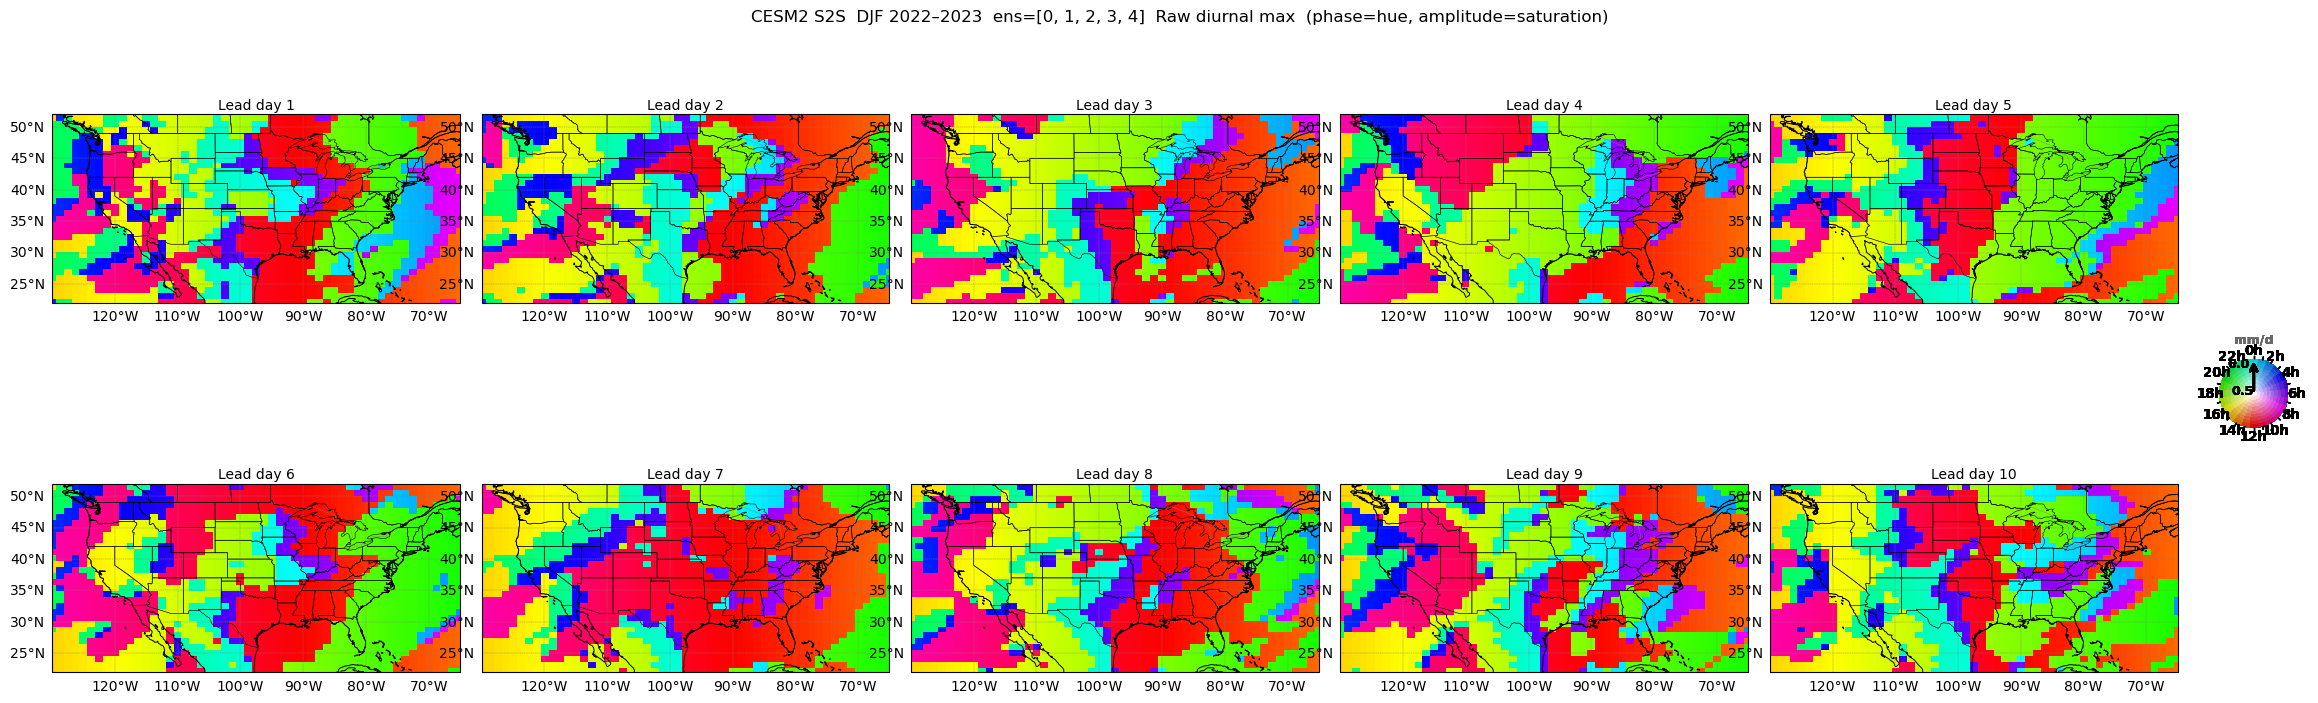

In [8]:
# ============================================================
# FIGURE 3: Raw Diurnal Max Panel (lead days 1–6)
# ============================================================

fig = fcutils.plot_forecast_panel(
    amplitude  = amp_raw_leads,
    phase_lst  = phase_lst_raw_leads,
    lat=lat, lon=lon,
    lead_days  = dc_leads['lead_day'].values,
    min_amp    = min_amp_raw,
    max_amp    = max_amp_raw,
    period_hours   = 24.0,
    hue_offset     = hue_offset,
    lat_range      = lat_range,
    lon_range      = lon_range,
    discrete_wheel = discrete_wheel,
    dt_hours       = dt_hours,
    show_states    = show_states,
    title      = (f'CESM2 S2S  {season} {year_start}–{year_end}  '
                  f'ens={ens_members}  Raw diurnal max  '
                  f'(phase=hue, amplitude=saturation)'),
)

fname = os.path.join(dir_fig,
    f'forecast_{domain}_{season}_{year_start}-{year_end}_evans_raw_max.png')
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f'Saved: {fname}')
plt.show()

  Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_regional_midwest.png
  Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_regional_southeast_us_land.png
  Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_regional_se_coast_ocean_ocean.png
Regional line plots: 3 figures saved to /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/


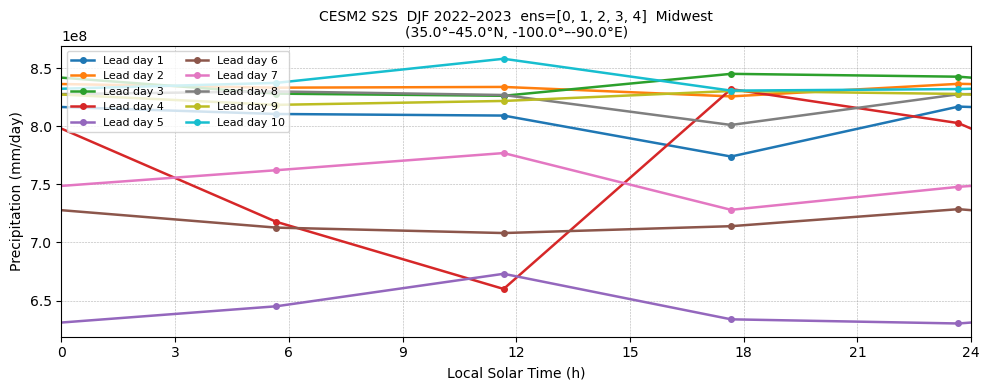

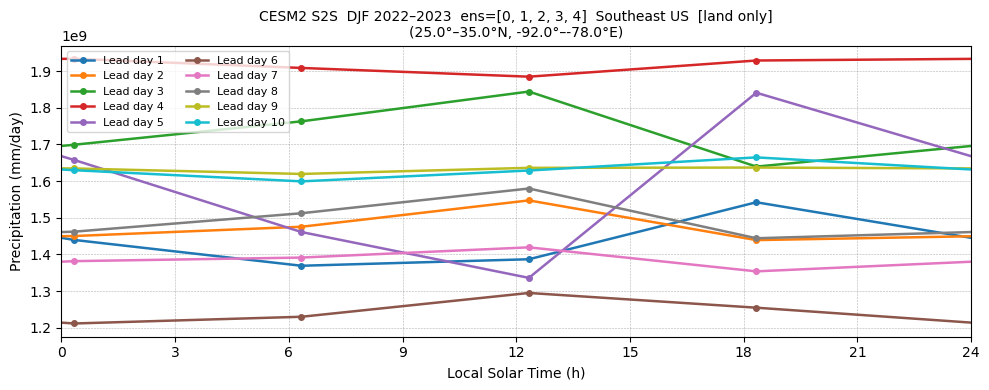

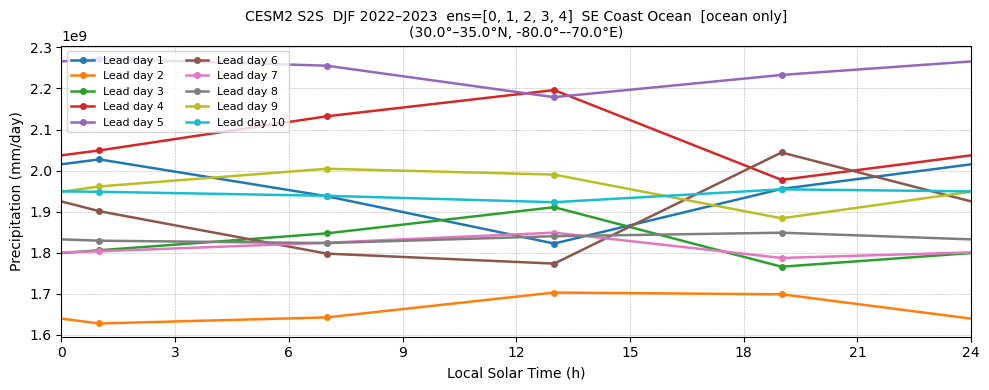

In [9]:
# ============================================================
# FIGURE 4: Regional Diurnal Cycle Line Plots
# One PNG per region saved to dir_fig
# ============================================================

importlib.reload(fcutils)

figs = fcutils.plot_regional_diurnal_lines(
    dc_leads,
    lat=lat, lon=lon,
    regions      = regions_line,
    dt_hours     = dt_hours,
    title_prefix = f'CESM2 S2S  {season} {year_start}–{year_end}  ens={ens_members}',
    dir_fig      = dir_fig,
    fname_prefix = f'forecast_{domain}_{season}_{year_start}-{year_end}_regional',
)

for fig in figs:
    plt.show(fig)
    plt.close(fig)

---
## Variable Diurnal Cycle Analysis
TMQ, U10, PSL — or any other variable in the hindcast files

In [10]:
# ============================================================
# VARIABLE SETTINGS
# Change var_name to switch between TMQ, U10, PSL, PRECT, etc.
# For PRECT: falls back to PRECC+PRECL if PRECT is absent in a file.
# Contour levels and Evans amplitude range are AUTO-DERIVED from the data
# after loading — override var_levels / var_min_amp / var_max_amp here if needed.
# ============================================================

importlib.reload(fcutils)

var_name = 'TMQ'     # 'TMQ' | 'U10' | 'PSL' | 'PRECT' | any CAM h3 variable

# Pull fixed metadata from VAR_SETTINGS
_vs       = fcutils.VAR_SETTINGS.get(var_name, {})
var_units = _vs.get('units',     '')
var_label = _vs.get('long_name', var_name)
var_scale = _vs.get('scale',     1.0)
var_cmap  = _vs.get('cmap',      None)

# These will be overridden with data-driven values in the load cell below.
# Set them here only if you want to force specific values.
var_levels  = None   # auto
var_min_amp = None   # auto
var_max_amp = None   # auto

print(f'Variable : {var_name}  ({var_label})')
print(f'Units    : {var_units}  (scale: ×{var_scale})')
print(f'Colormap : {var_cmap}')
print('Contour levels and amp range will be derived from the loaded data.')

Variable : TMQ  (Total Precipitable Water)
Units    : kg/m²  (scale: ×1.0)
Colormap : Blues
Contour levels and amp range will be derived from the loaded data.


In [11]:
# ============================================================
# LOAD variable diurnal composite + derive plot ranges
# ============================================================

print(f'Loading {var_name}: {len(start_dates)} start dates × '
      f'{len(ens_members)} members → {nlead_days} lead days ...')

dc_var = fcutils.load_forecast_diurnal_var(
    data_dir    = data_dir,
    start_dates = start_dates,
    ens_members = ens_members,
    nlead_days  = nlead_days,
    dt_hours    = dt_hours,
    var_name    = var_name,
    scale       = var_scale,
)

lat_v = dc_var['lat'].values
lon_v = dc_var['lon'].values

print(f'\ndc_{var_name} shape: {dc_var.shape}')
print(f'  time-of-day (UTC h): {dc_var["time_of_day"].values}')
for d in range(nlead_days):
    m = float(np.nanmean(dc_var.isel(lead_day=d)))
    print(f'  Lead day {d+1}: mean = {m:.4g} {var_units}')

# ── Auto-derive contour levels and Evans amplitude range from data ───────────
_ranges     = fcutils.auto_plot_ranges(dc_var)
var_levels  = _ranges['levels']
var_min_amp = _ranges['min_amp']
var_max_amp = _ranges['max_amp']

print(f'\nAuto plot ranges for {var_name}:')
print(f'  Mean-map levels : {[f"{v:.4g}" for v in var_levels]}')
print(f'  Evans amp range : {var_min_amp:.4g} – {var_max_amp:.4g} {var_units}')
print('  (override var_levels / var_min_amp / var_max_amp in the cell above if needed)')

Loading TMQ: 22 start dates × 5 members → 10 lead days ...
  100/110  loaded=100  missing=0  no_var=0
  Done: 110/110 files loaded  (0 missing, 0 without 'TMQ')

dc_TMQ shape: (10, 4, 192, 288)
  time-of-day (UTC h): [ 0.  6. 12. 18.]
  Lead day 1: mean = 17.99 kg/m²
  Lead day 2: mean = 18.08 kg/m²
  Lead day 3: mean = 18.03 kg/m²
  Lead day 4: mean = 17.99 kg/m²
  Lead day 5: mean = 17.98 kg/m²
  Lead day 6: mean = 17.99 kg/m²
  Lead day 7: mean = 18.01 kg/m²
  Lead day 8: mean = 18.03 kg/m²
  Lead day 9: mean = 18.03 kg/m²
  Lead day 10: mean = 18.03 kg/m²

Auto plot ranges for TMQ:
  Mean-map levels : ['0', '5', '10', '15', '20', '25', '30', '35', '40', '45', '50', '55']
  Evans amp range : 0.037 – 1 kg/m²
  (override var_levels / var_min_amp / var_max_amp in the cell above if needed)


In [12]:
# ============================================================
# HARMONICS for variable
# ============================================================

amp_v, ph_utc_v, var_exp_v, mean_v = fcutils.compute_lead_harmonics(
    dc_var, n_harm=n_harm, dt_hours=dt_hours)

# UTC phase → LST
ph_lst_v = np.zeros_like(ph_utc_v)
for d in range(nlead_days):
    for ih in range(n_harm):
        ph_lst_v[d, ih] = fcutils.phase_utc_to_lst(
            ph_utc_v[d, ih], lon_v, harm_periods[ih])

print(f'{var_name} harmonic analysis complete.')
for d in range(nlead_days):
    for ih in range(n_harm):
        print(f'  Lead day {d+1}  H{ih+1}: '
              f'amp_max={np.nanmax(amp_v[d,ih]):.3f} {var_units}  '
              f'var_exp={np.nanmean(var_exp_v[d,ih]):.1%}')

TMQ harmonic analysis complete.
  Lead day 1  H1: amp_max=4.634 kg/m²  var_exp=72.7%
  Lead day 1  H2: amp_max=3.204 kg/m²  var_exp=27.3%
  Lead day 2  H1: amp_max=3.318 kg/m²  var_exp=74.0%
  Lead day 2  H2: amp_max=1.985 kg/m²  var_exp=26.0%
  Lead day 3  H1: amp_max=3.348 kg/m²  var_exp=74.4%
  Lead day 3  H2: amp_max=2.191 kg/m²  var_exp=25.6%
  Lead day 4  H1: amp_max=2.774 kg/m²  var_exp=74.5%
  Lead day 4  H2: amp_max=1.971 kg/m²  var_exp=25.5%
  Lead day 5  H1: amp_max=3.760 kg/m²  var_exp=75.4%
  Lead day 5  H2: amp_max=2.688 kg/m²  var_exp=24.6%
  Lead day 6  H1: amp_max=2.943 kg/m²  var_exp=75.0%
  Lead day 6  H2: amp_max=1.790 kg/m²  var_exp=25.0%
  Lead day 7  H1: amp_max=2.978 kg/m²  var_exp=74.2%
  Lead day 7  H2: amp_max=1.604 kg/m²  var_exp=25.8%
  Lead day 8  H1: amp_max=2.635 kg/m²  var_exp=74.8%
  Lead day 8  H2: amp_max=1.148 kg/m²  var_exp=25.2%
  Lead day 9  H1: amp_max=2.790 kg/m²  var_exp=75.0%
  Lead day 9  H2: amp_max=1.205 kg/m²  var_exp=25.0%
  Lead day 10 

Blues
Blues
Blues
Blues
Blues
Blues
Blues
Blues
Blues
Blues
Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_TMQ_mean.png


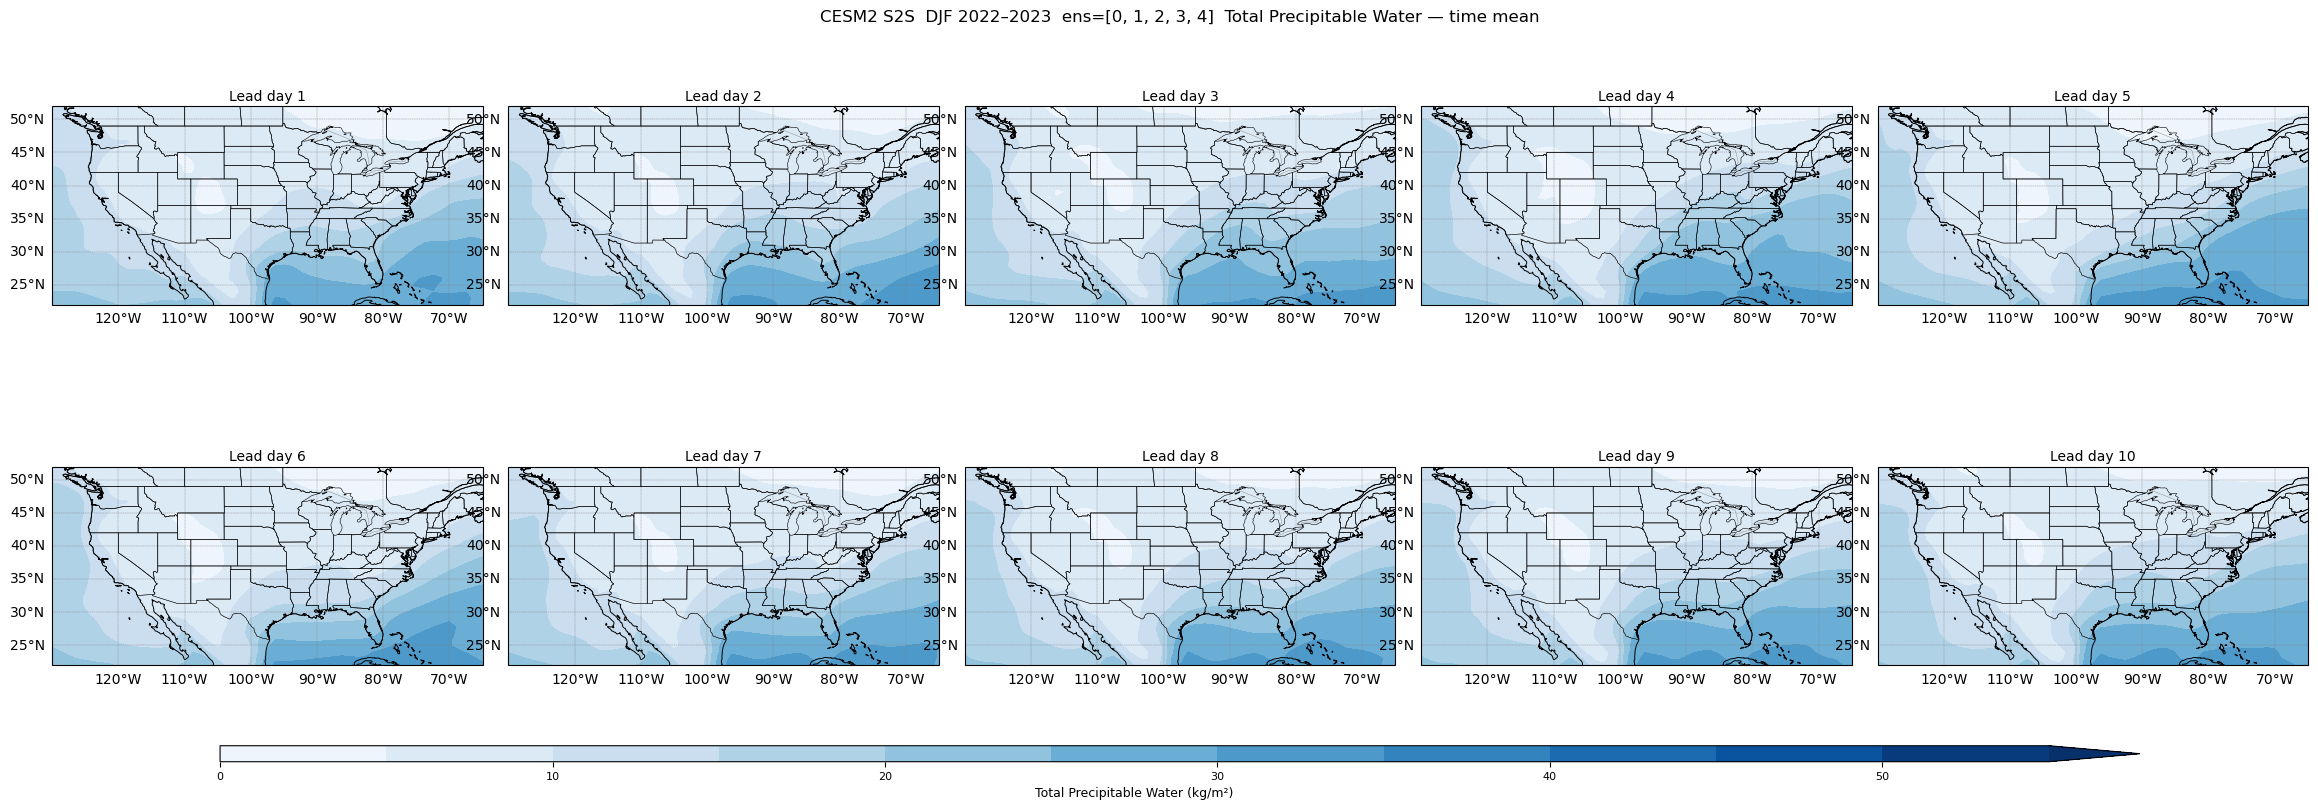

In [13]:
# ============================================================
# FIGURE V1: Mean value panel
# ============================================================

fig = fcutils.plot_forecast_mean_panel(
    mean_v, lat_v, lon_v,
    lead_days   = dc_var['lead_day'].values,
    lat_range   = lat_range,
    lon_range   = lon_range,
    show_states = show_states,
    n_cols      = n_cols,
    levels      = var_levels,
    cmap        = var_cmap,
    units       = f'{var_label} ({var_units})',
    title       = (f'CESM2 S2S  {season} {year_start}–{year_end}  '
                   f'ens={ens_members}  {var_label} — time mean'),
)
fname = os.path.join(dir_fig,
    f'forecast_{domain}_{season}_{year_start}-{year_end}_{var_name}_mean.png')
fig.savefig(fname, dpi=150, bbox_inches='tight')
print(f'Saved: {fname}')
plt.show()
plt.close(fig)

Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_TMQ_evans_H1_diurnal.png


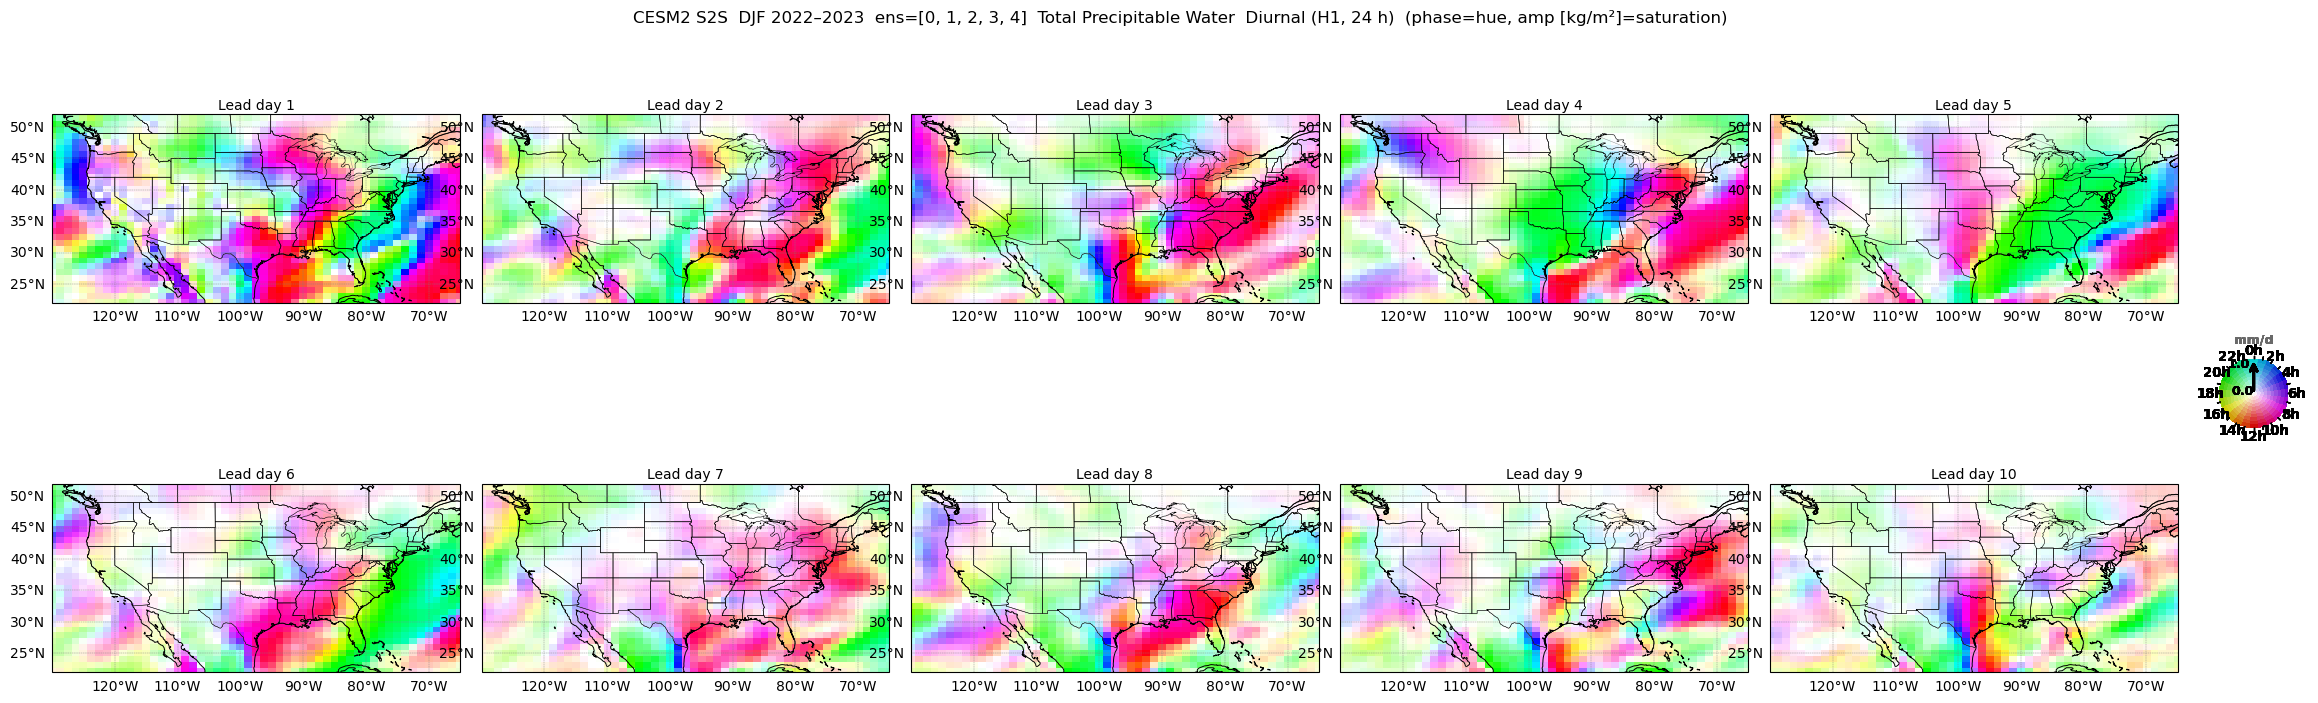

Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_TMQ_evans_H2_semidiurnal.png


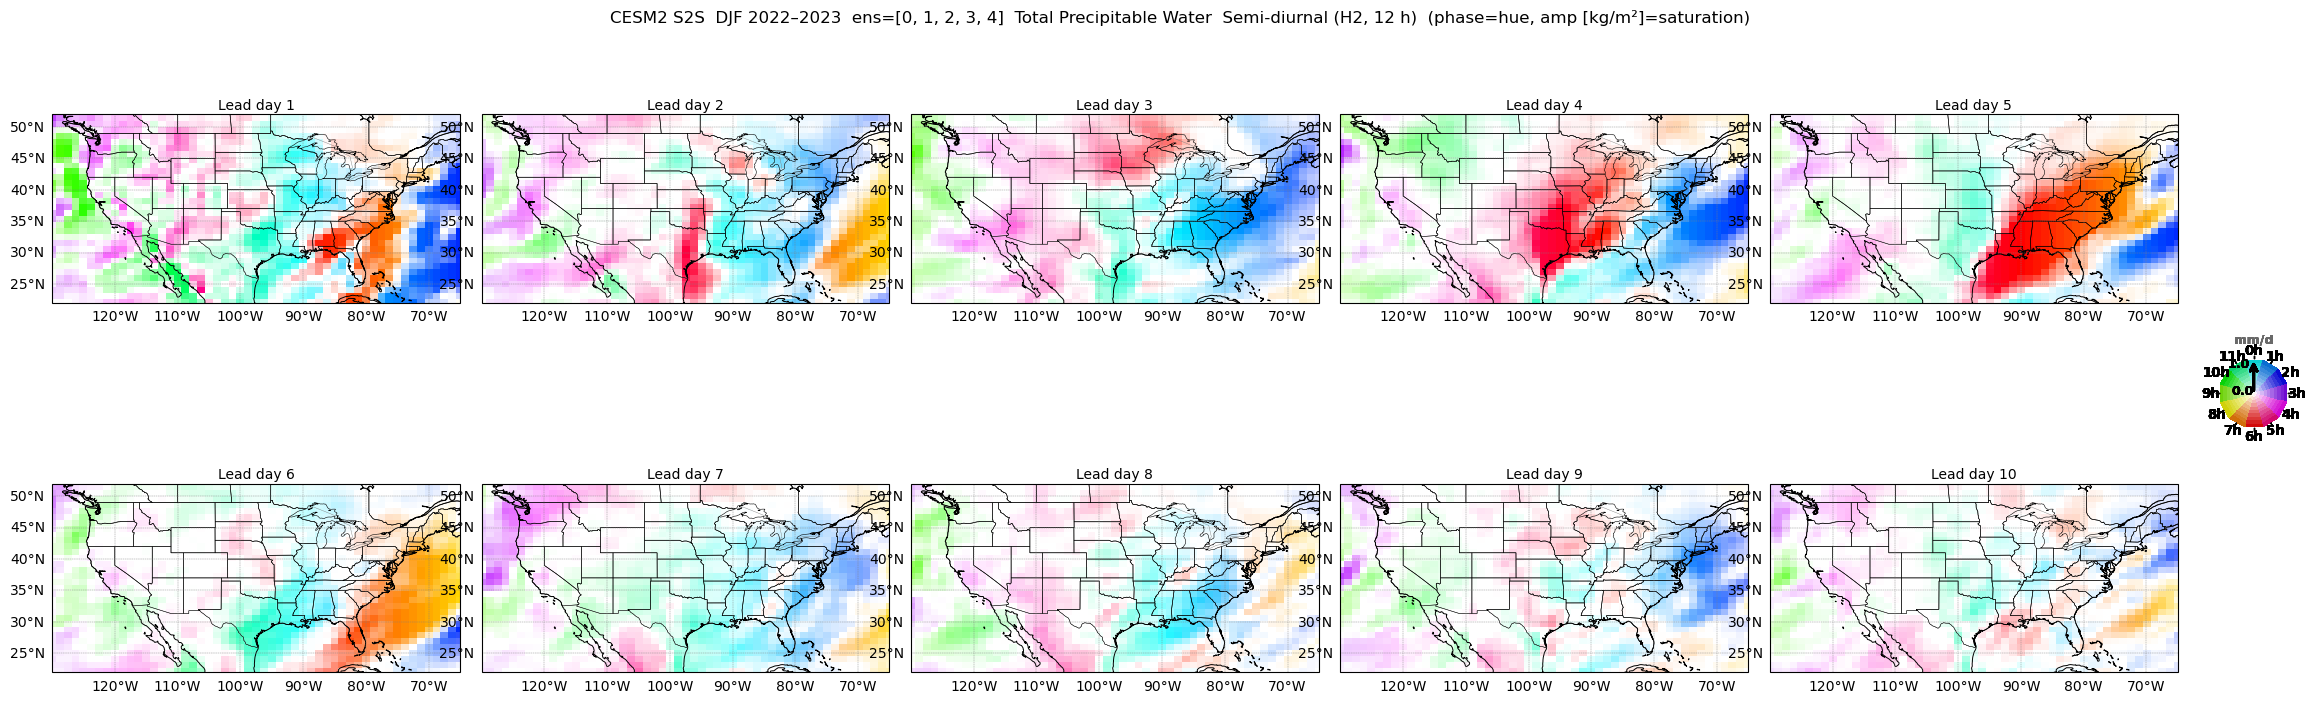

In [14]:
# ============================================================
# FIGURE V2: Evans phase/amplitude panels (H1 diurnal)
# ============================================================

for ih in range(n_harm):
    fig = fcutils.plot_forecast_panel(
        amplitude    = amp_v[:, ih],
        phase_lst    = ph_lst_v[:, ih],
        lat=lat_v, lon=lon_v,
        lead_days    = dc_var['lead_day'].values,
        min_amp      = var_min_amp,
        max_amp      = var_max_amp,
        period_hours = harm_periods[ih],
        hue_offset   = hue_offset,
        lat_range    = lat_range,
        lon_range    = lon_range,
        discrete_wheel = discrete_wheel,
        dt_hours     = dt_hours,
        show_states  = show_states,
        n_cols       = n_cols,
        title        = (f'CESM2 S2S  {season} {year_start}–{year_end}  '
                        f'ens={ens_members}  {var_label}  {harm_names[ih]}  '
                        f'(phase=hue, amp [{var_units}]=saturation)'),
    )
    fname = os.path.join(dir_fig,
        f'forecast_{domain}_{season}_{year_start}-{year_end}'
        f'_{var_name}_evans_{harm_fnames[ih]}.png')
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    print(f'Saved: {fname}')
    plt.show()
    plt.close(fig)

  Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_TMQ_regional_midwest.png
  Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_TMQ_regional_southeast_us_land.png
  Saved: /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/forecast_CONUS_DJF_2022-2023_TMQ_regional_se_coast_ocean_ocean.png
Regional line plots: 3 figures saved to /glade/u/home/rneale/python/python-figs/diurnal_cycle/forecast/


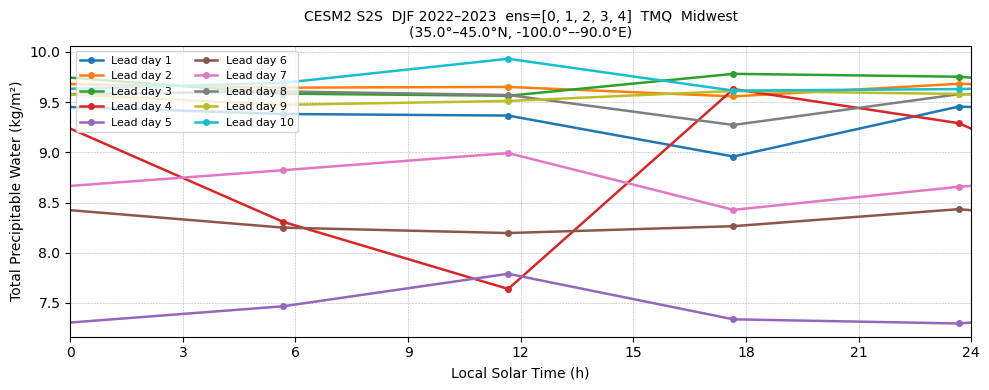

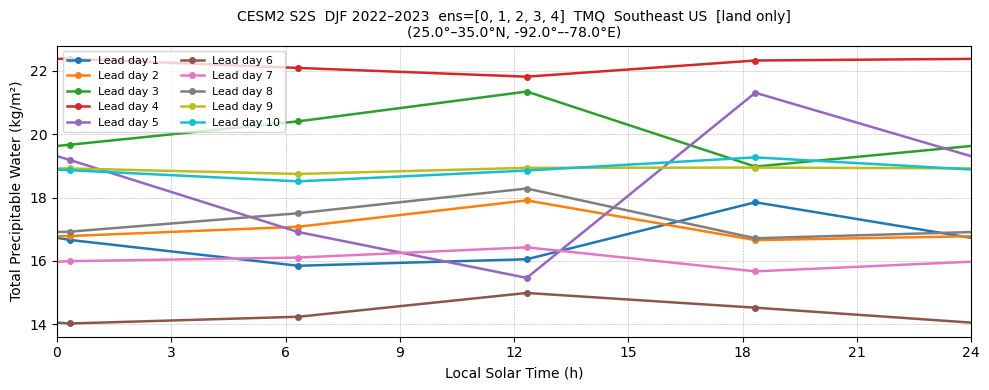

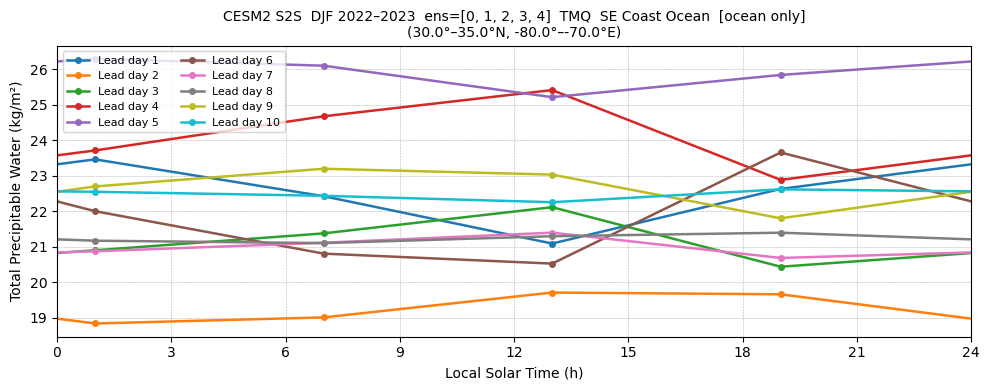

In [15]:
# ============================================================
# FIGURE V3: Regional diurnal line plots
# ============================================================

figs = fcutils.plot_regional_diurnal_lines(
    dc_var,
    lat=lat_v, lon=lon_v,
    regions      = regions_line,
    dt_hours     = dt_hours,
    ylabel       = f'{var_label} ({var_units})',
    title_prefix = f'CESM2 S2S  {season} {year_start}–{year_end}  ens={ens_members}  {var_name}',
    dir_fig      = dir_fig,
    fname_prefix = f'forecast_{domain}_{season}_{year_start}-{year_end}_{var_name}_regional',
)
for fig in figs:
    plt.show(fig)
    plt.close(fig)